In [ ]:
!pip install kagglehub -q

In [ ]:
import os
import cv2
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import kagglehub

from PIL import Image

from tensorflow.keras import layers, models

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [ ]:
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print(path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
/kaggle/input/brain-tumor-mri-dataset


In [ ]:
train_path = os.path.join(path,"Training")

test_path = os.path.join(path,"Testing")

In [ ]:
print(os.listdir(train_path))

['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
classes = sorted(os.listdir(train_path))

train_count = []

test_count = []

for cls in classes:

    train_count.append(
        len(os.listdir(os.path.join(train_path,cls)))
    )

    test_count.append(
        len(os.listdir(os.path.join(test_path,cls)))
    )

dataset = pd.DataFrame({

    "Class":classes,

    "Training Images":train_count,

    "Testing Images":test_count

})

dataset

,Class,Training Images,Testing Images
0,glioma,1400,400
1,meningioma,1400,400
2,notumor,1400,400
3,pituitary,1400,400


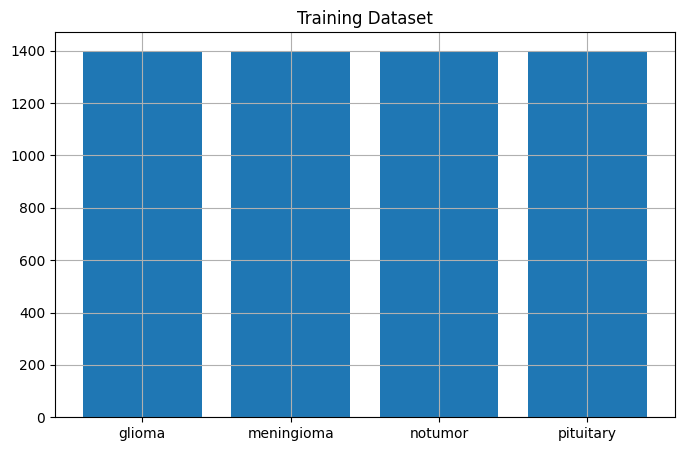

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(classes,train_count)

plt.title("Training Dataset")

plt.grid()

plt.show()

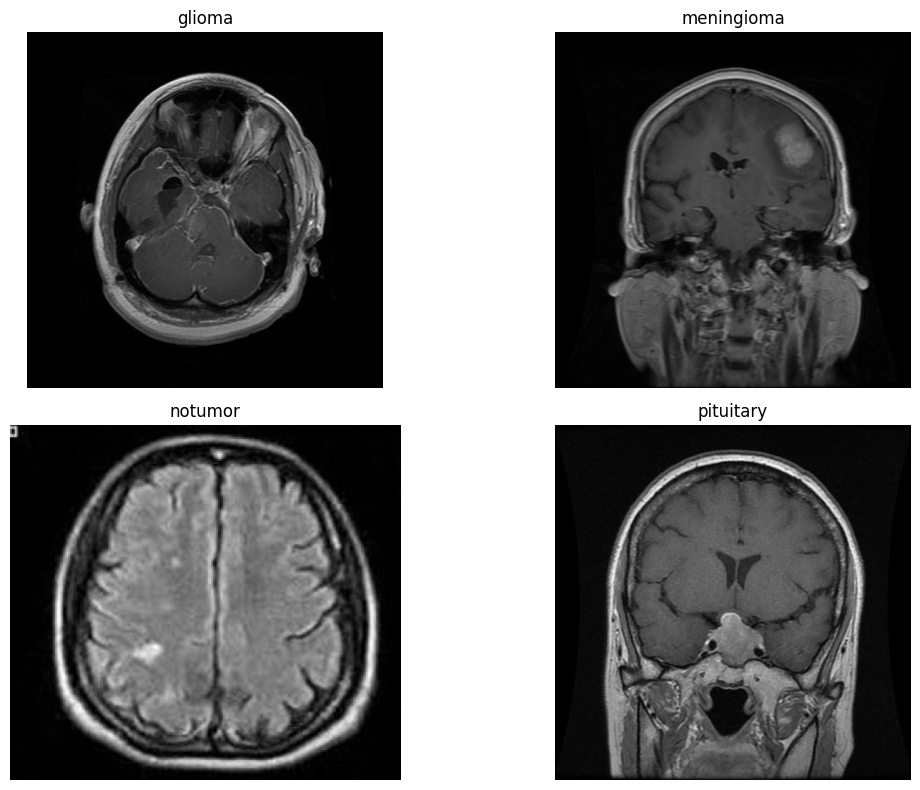

In [ ]:
plt.figure(figsize=(12,8))

for i,cls in enumerate(classes):

    folder=os.path.join(train_path,cls)

    img=random.choice(os.listdir(folder))

    image=Image.open(os.path.join(folder,img))

    plt.subplot(2,2,i+1)

    plt.imshow(image,cmap="gray")

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
IMG_SIZE=64

In [ ]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=10,

    width_shift_range=0.05,

    height_shift_range=0.05,

    horizontal_flip=True,

    zoom_range=0.05

)

test_datagen=ImageDataGenerator(

    rescale=1./255

)

In [ ]:
train_data = train_datagen.flow_from_directory(

    train_path,

    target_size=(64,64),

    color_mode="grayscale",

    batch_size=32,

    class_mode="sparse",

    shuffle=True

)

Found 5600 images belonging to 4 classes.


In [ ]:
test_data = test_datagen.flow_from_directory(

    test_path,

    target_size=(64,64),

    color_mode="grayscale",

    batch_size=32,

    class_mode="sparse",

    shuffle=False

)

Found 1600 images belonging to 4 classes.


In [ ]:
model = models.Sequential([

    # ==========================
    # Block 1
    # ==========================

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(64,64,1)
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),

    # ==========================
    # Block 2
    # ==========================

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),

    # ==========================
    # Block 3
    # ==========================

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),

    # ==========================

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.50),

    layers.Dense(
        4,
        activation='softmax'
    )

])

In [ ]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,252 (1.16 MB)

 Trainable params: 304,356 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
lr_reducer = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=4,

    min_lr=1e-6,

    verbose=1

)

In [ ]:
early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=12,

    restore_best_weights=True,

    verbose=1,

    mode='max'

)

In [ ]:
checkpoint = ModelCheckpoint(

    "Best_BrainTumor_CNN.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1

)

In [ ]:
start = time.time()

In [ ]:
history = model.fit(

    train_data,

    epochs=40,

    validation_data=test_data,

    callbacks=[
        lr_reducer,
        early_stop,
        checkpoint
    ]

)

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6184 - loss: 1.0168
Epoch 1: val_accuracy improved from None to 0.25000, saving model to Best_BrainTumor_CNN.keras

Epoch 1: finished saving model to Best_BrainTumor_CNN.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.6859 - loss: 0.8076 - val_accuracy: 0.2500 - val_loss: 3.8032 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7533 - loss: 0.6324
Epoch 2: val_accuracy improved from 0.25000 to 0.27875, saving model to Best_BrainTumor_CNN.keras

Epoch 2: finished saving model to Best_BrainTumor_CNN.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.7720 - loss: 0.5811 - val_accuracy: 0.2788 - val_loss: 3.7388 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8037 - loss: 0.5159
Epoch 3: val_accuracy improved from 0.27875 to 0.62625, saving model to Best_BrainTumor_CNN.keras

Epoch 3: finished saving model to Best_BrainTum

In [ ]:
end = time.time()

print("="*40)

print("Training Completed")

print("="*40)

print("Training Time :",

      round((end-start)/60,2),

      "Minutes")

Training Completed
Training Time : 139.88 Minutes


In [ ]:
model.save("BrainTumorCNN_Final.keras")

print("Model Saved Successfully")

Model Saved Successfully


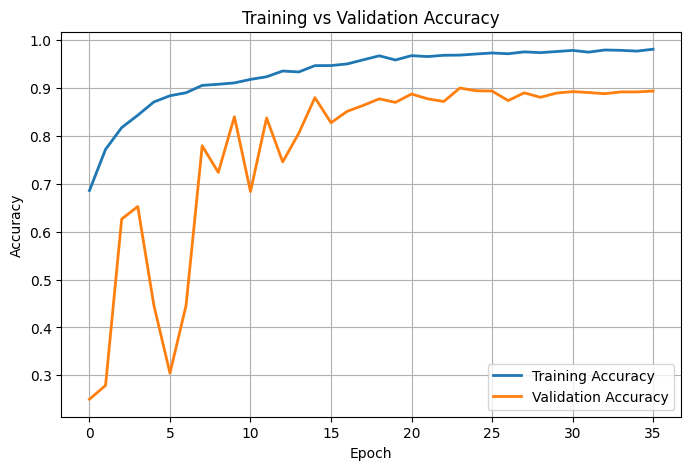

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)

plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("Accuracy_Graph.png")

plt.show()

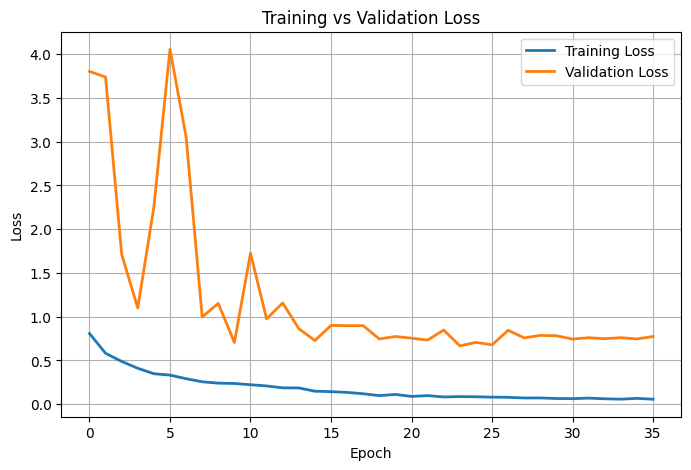

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)

plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig("Loss_Graph.png")

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)

print("="*50)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")

print(f"Test Loss     : {test_loss:.4f}")

print("="*50)

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 276ms/step - accuracy: 0.9000 - loss: 0.6659
Test Accuracy : 90.00%
Test Loss     : 0.6659


In [ ]:
predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)

y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 276ms/step


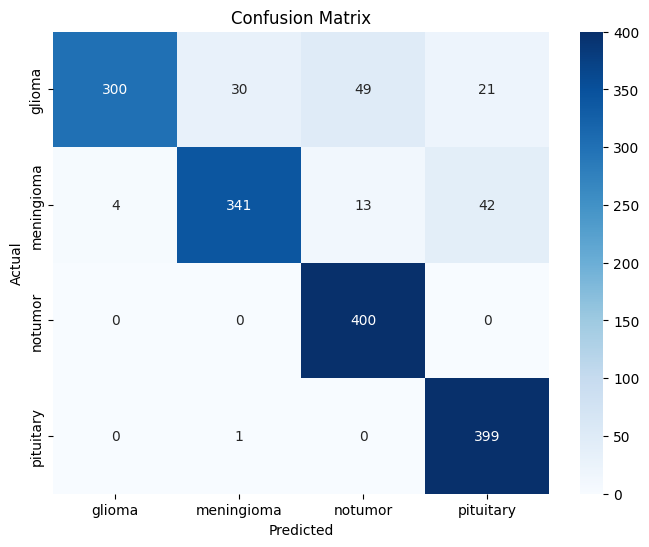

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("Confusion_Matrix.png")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.99      0.75      0.85       400
  meningioma       0.92      0.85      0.88       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.86      1.00      0.93       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step


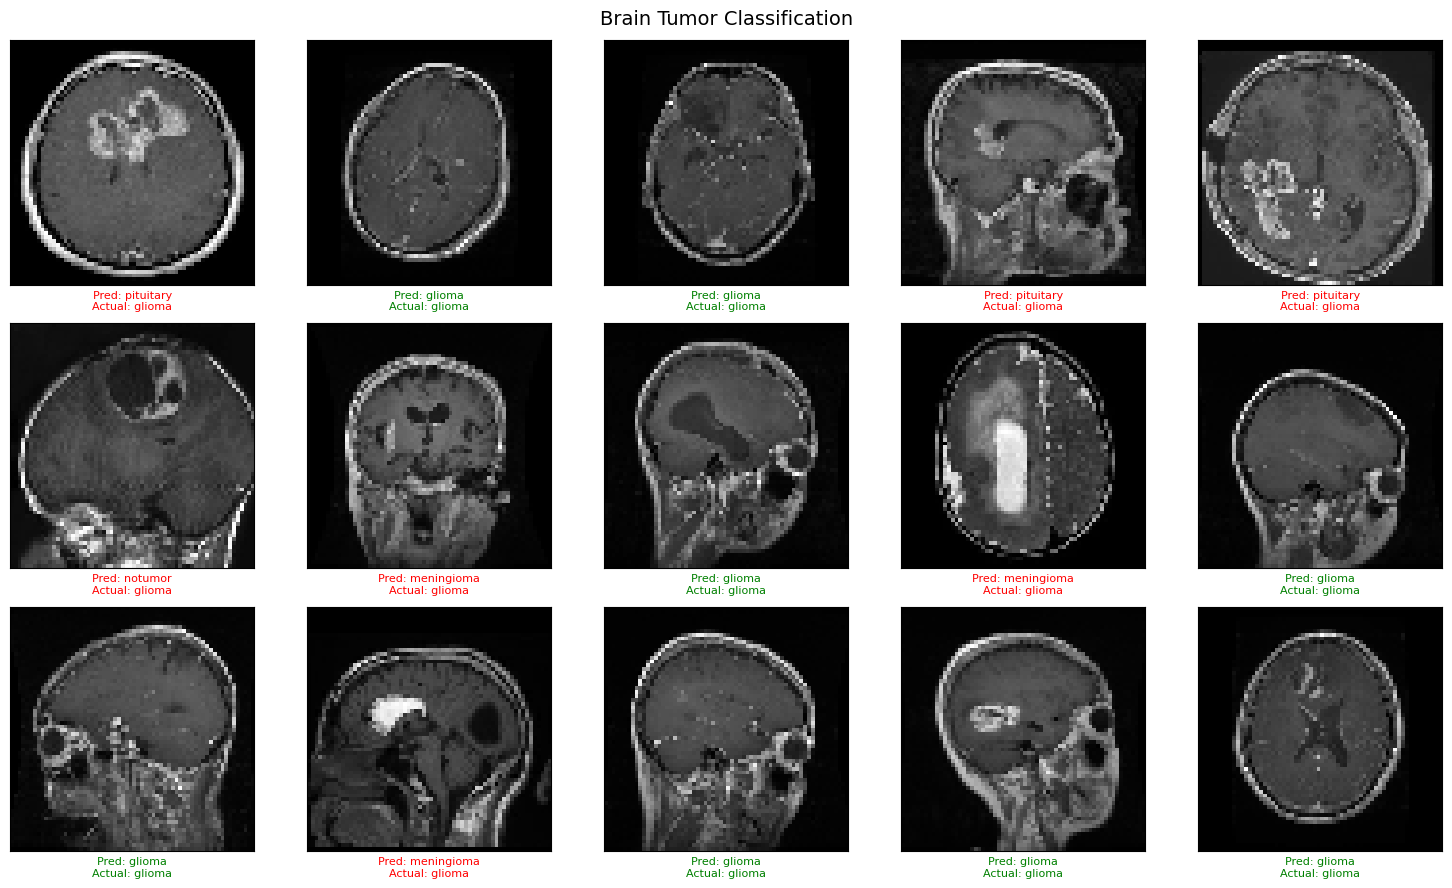

In [ ]:
test_data.reset()

test_images, test_labels = next(iter(test_data))

pred = model.predict(test_images)

plt.figure(figsize=(15,9))

for i in range(15):

    plt.subplot(3,5,i+1)

    plt.imshow(
        test_images[i].reshape(64,64),
        cmap='gray'
    )

    predicted = class_names[np.argmax(pred[i])]

    actual = class_names[int(test_labels[i])]

    color = "green" if predicted==actual else "red"

    plt.xlabel(
        f"Pred: {predicted}\nActual: {actual}",
        color=color,
        fontsize=8
    )

    plt.xticks([])

    plt.yticks([])

plt.suptitle(
    "Brain Tumor Classification",
    fontsize=14
)

plt.tight_layout()

plt.show()

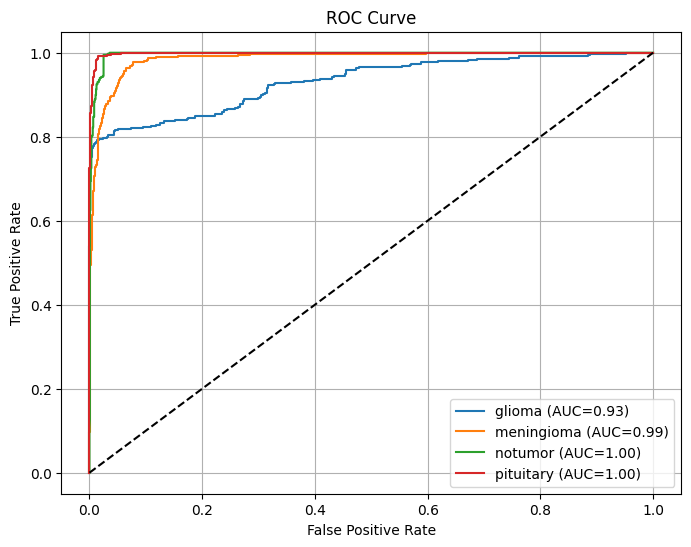

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(4):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        predictions[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.legend()

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.grid(True)

plt.savefig("ROC_Curve.png")

plt.show()

In [ ]:
dashboard = pd.DataFrame({

    "Metric":[
        "Training Accuracy",
        "Validation Accuracy",
        "Testing Accuracy",
        "Training Time (Minutes)",
        "Number of Classes"
    ],

    "Value":[
        f"{history.history['accuracy'][-1]*100:.2f}%",
        f"{history.history['val_accuracy'][-1]*100:.2f}%",
        f"{test_accuracy*100:.2f}%",
        round((end-start)/60,2),
        len(class_names)
    ]

})

dashboard

,Metric,Value
0,Training Accuracy,98.11%
1,Validation Accuracy,89.38%
2,Testing Accuracy,90.00%
3,Training Time (Minutes),139.88
4,Number of Classes,4


In [ ]:
import os
import shutil

os.makedirs("Results",exist_ok=True)

files = [

    "Accuracy_Graph.png",

    "Loss_Graph.png",

    "Confusion_Matrix.png",

    "ROC_Curve.png",

    "BrainTumorCNN_Final.keras"

]

for file in files:

    if os.path.exists(file):

        shutil.copy(file,"Results")

print("Results Saved Successfully")

Results Saved Successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mri.jpg to mri.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


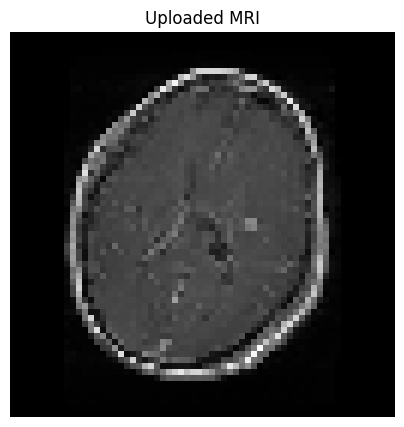

Prediction : Glioma
Confidence : 99.99%


In [ ]:
from tensorflow.keras.preprocessing import image

class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

filename = list(uploaded.keys())[0]

img = image.load_img(
    filename,
    color_mode='grayscale',
    target_size=(64,64)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100

plt.figure(figsize=(5,5))
plt.imshow(img,cmap='gray')
plt.title("Uploaded MRI")
plt.axis("off")
plt.show()

print("="*40)
print("Prediction :",predicted_class)
print("Confidence : {:.2f}%".format(confidence))
print("="*40)

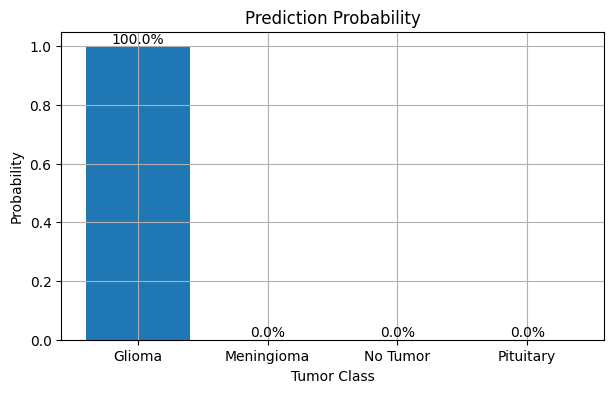

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(class_names,prediction[0])

plt.ylabel("Probability")

plt.xlabel("Tumor Class")

plt.title("Prediction Probability")

for i,v in enumerate(prediction[0]):
    plt.text(i,v+0.01,f"{v*100:.1f}%",ha='center')

plt.grid(True)

plt.show()

In [ ]:
history_df = pd.DataFrame({

    "Image":[filename],

    "Prediction":[predicted_class],

    "Confidence":[round(confidence,2)]

})

history_df.to_csv(
    "Prediction_History.csv",
    index=False
)

print(history_df)

     Image Prediction  Confidence
0  mri.jpg     Glioma   99.989998


50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 377ms/step


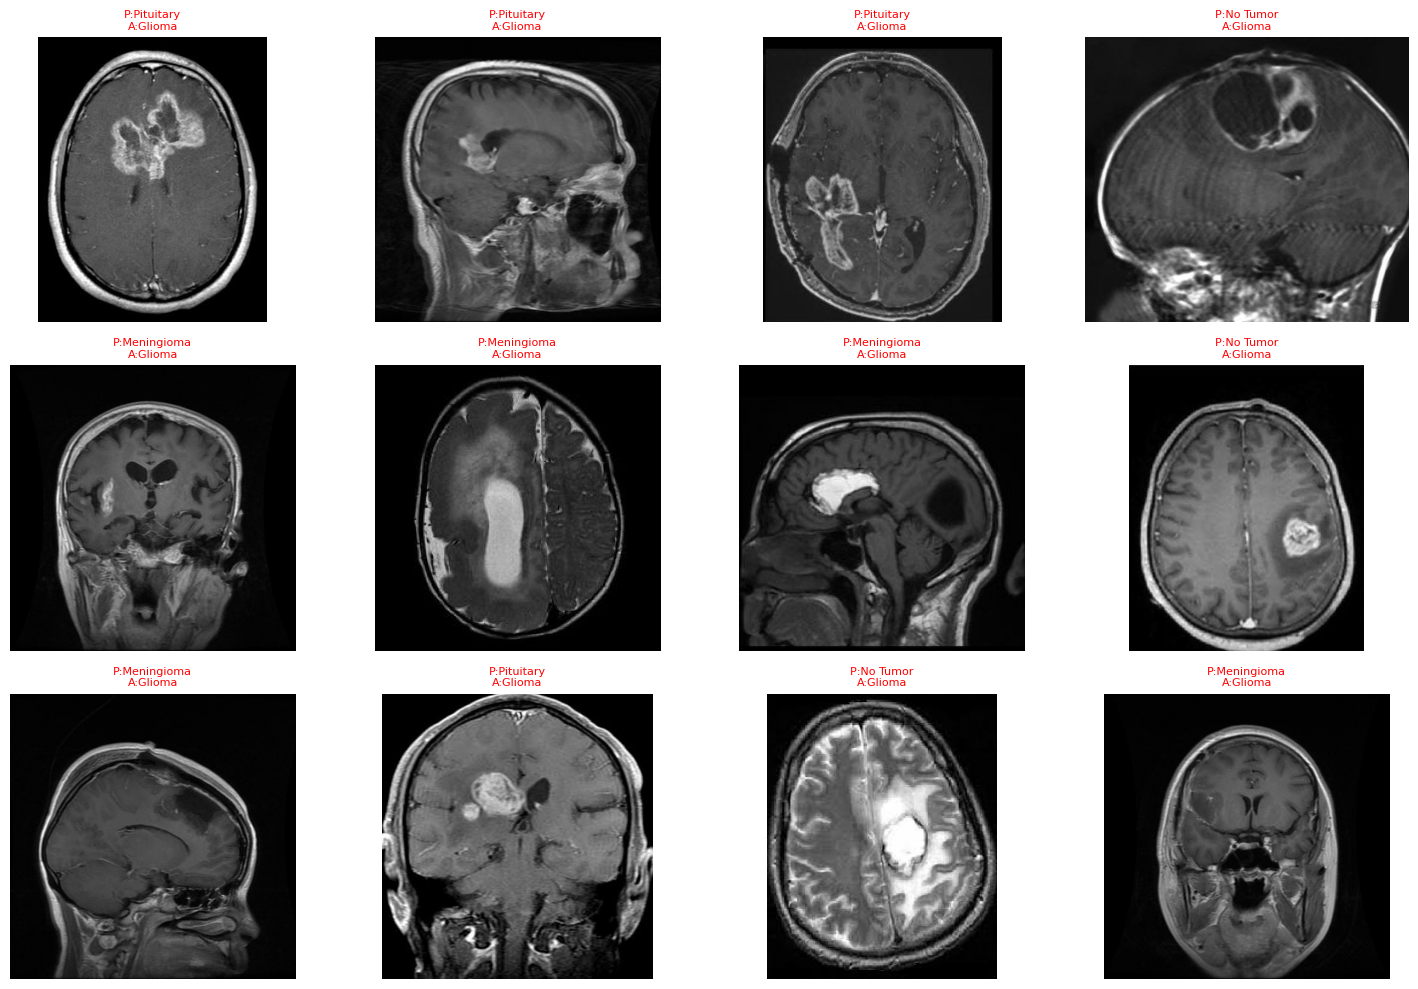

In [ ]:
test_data.reset()

predictions = model.predict(test_data)

predicted = np.argmax(predictions,axis=1)

actual = test_data.classes

misclassified = np.where(predicted!=actual)[0]

plt.figure(figsize=(15,10))

for i,index in enumerate(misclassified[:12]):

    plt.subplot(3,4,i+1)

    img_path = test_data.filepaths[index]

    img = Image.open(img_path)

    plt.imshow(img,cmap="gray")

    plt.title(
        f"P:{class_names[predicted[index]]}\nA:{class_names[actual[index]]}",
        fontsize=8,
        color="red"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

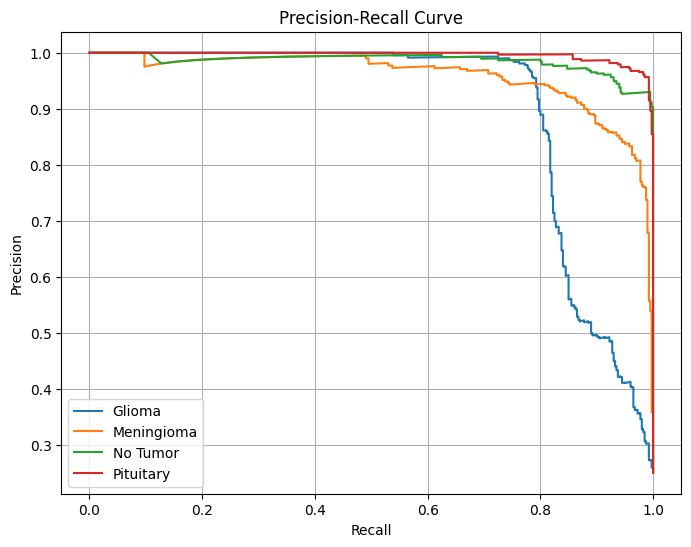

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve

y_true_bin = label_binarize(y_true,classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(4):

    precision,recall,_ = precision_recall_curve(
        y_true_bin[:,i],
        predictions[:,i]
    )

    plt.plot(
        recall,
        precision,
        label=class_names[i]
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()